In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
import random

%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [3]:
# get distinct chars across all words -- build vocab
chars = sorted(list(set("".join(words))))

# map chars to and from integers
# 0th char will be "." which denotes start/end of a word
char_to_int = {ch: idx + 1 for idx, ch in enumerate(chars)}
char_to_int["."] = 0
int_to_char = {idx: ch for ch, idx in char_to_int.items()}

print(char_to_int)
print(int_to_char)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
# build train, eval and test datasets
# X: 3 chars --> Y: next char
# For word "emma"
# ... --> e
# ..e --> m
# .em --> m
# emm --> a
# mma --> .

context_length = 3


def get_dataset(words):
    X, y = [], []
    for word in words:
        # start at [., ., .] case whose int rep would be [0, 0, 0]
        context = [0] * context_length
        for ch in word + ".":
            ch_idx = char_to_int[ch]
            X.append(context)
            y.append(ch_idx)
            # update context
            context = context[1:] + [ch_idx]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y


# split the dataset into train, val and test into 80-10-10 split
random.seed(42)
random.shuffle(words)

limit1 = int(0.8 * len(words))
limit2 = int(0.9 * len(words))

X_train, y_train = get_dataset(words=words[:limit1])
X_val, y_val = get_dataset(words=words[limit1:limit2])
X_test, y_test = get_dataset(words=words[limit2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


# Part 1:
(1) Initial loss too high.
- Reason: overconfident logits.
- Fix: Squash W2. This will bring initial loss close to our back-of-envelope value

(2) High number of tanh() activations lie on -1 or +1 during initialization (first forward pass)
- Reason: Preactivation layer values are too high or too low --> tanh/activations saturation
- Consequence: tanh = -/+1 --> tanh.grad = 0 --> Vanishing gradients
- Fix: Squash W1 so preactivations fall within active range of tanh() 

In [ ]:
# Initialize parameters of the network
# C --> embedding matrix. Embeds each character into an d-dimensional vector. Here, d=2
# (W1, b1) and (W2, b2) --> Two MLP layers

# Architecture
# input --> input_thro_2d_embedding --> flatten --> layer 1 (100 neurons)   --> layer 2 (27 neurons)
# (n, 3)--> (n, 3, 2)               --> (n, 6)  --> layer outputs: (n, 100) --> layer outputs (n, 27)

# Layer 2 is intentionally set to have 27 neurons to give us (n, 27) as output
# It tells what score our model gives to each of the 27 characters for a given example.
# We would want our model to give maximum score to the character next in input example's sequence.

n_emb = 10
n_hidden = 200
context_length = 3
vocab_size = len(chars) + 1

g = torch.Generator().manual_seed(6)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = (
    torch.randn((n_emb * context_length, n_hidden), generator=g)
    * (5 / 3)
    / ((n_emb * context_length) ** 0.5)
)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [ ]:
# Training using batches
max_steps = 200000
batch_size = 32
lossi = []
stepsi = []

for i in range(max_steps):
    # ------- batching ----------
    ix = torch.randint(low=0, high=X_train.shape[0], size=(batch_size,), generator=g)
    Xb, yb = X_train[ix], y_train[ix]

    # ------- forward pass ----------
    emb = C[Xb]  # embed characters in 2 dimensions --> (n, 3, 2)
    embcat = emb.view(emb.shape[0], -1)  # concatenate vectors for each char --> (n, 6)
    hpreact = embcat @ W1 + b1  # linear layer --> (n, 100)
    h = torch.tanh(hpreact)  # activation layer --> (n, 100)
    logits = h @ W2 + b2  # logits --> (n, 27)

    loss = F.cross_entropy(logits, yb)

    # ------- backprop ----------
    for p in parameters:
        p.grad = None
    loss.backward()

    # ------- gradient descent -------
    # lr decay
    lr = 0.1 if i < max_steps // 2 else 0.001
    # parameter update
    for p in parameters:
        p.data += -lr * p.grad

    # -------- log & print -----------------
    lossi.append(loss)
    stepsi.append(i)

    if i % 10000 == 0:
        print(f"Step: {i}, Loss: {loss}")
    break


In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))
fig.subplots_adjust(hspace=0.5)

ax[0].imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")
ax[0].set_title(f"hidden layer activation: ({batch_size} examples, {n_hidden} neurons)")
ax[1].hist(h.view(-1).tolist(), bins=50)
ax[1].set_title("hidden layer activation histogram")
ax[2].hist(hpreact.view(-1).tolist(), bins=50)
ax[2].set_title("preactivations histogram");

In [ ]:
# full set forward pass using trained model
@torch.no_grad()
def get_loss(X, y):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    return loss


train_loss = get_loss(X=X_train, y=y_train)
val_loss = get_loss(X=X_val, y=y_val)

print(f"Train loss: {train_loss} | Val loss: {val_loss}")


# Part 2: Implement BatchNorm

Linear layer (preactivation) --> BatchNorm layer --> Non-linearity (activation)

In [ ]:
# Initialize parameters of the network
n_emb = 10
n_hidden = 200
context_length = 3
vocab_size = len(chars) + 1

g = torch.Generator().manual_seed(6)
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = (
    torch.randn((n_emb * context_length, n_hidden), generator=g)
    * (5 / 3)
    / ((n_emb * context_length) ** 0.5)
)
# b1 = torch.randn(n_hidden, generator=g) * 0.01 # layer bias not needed when using batchnorm layer following it
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# batchnorm parameter initialization
# we want to start with gain = 1 and bias = 0. These params will be learned while training
# in PyTorch nomenclature, bngain (gamma) and bnbias (beta) are referred to as "buffers"
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
# running mean and std for running predictions post-training [no grad required]
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))


parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [ ]:
# Training using batches
max_steps = 200000
batch_size = 32
lossi = []
stepsi = []

for i in range(max_steps):
    # ------- batching ----------
    ix = torch.randint(low=0, high=X_train.shape[0], size=(batch_size,), generator=g)
    Xb, yb = X_train[ix], y_train[ix]

    # ------- forward pass ----------
    # embedding layer
    emb = C[Xb]  # embed characters in 2 dimensions --> (n, 3, 2)
    embcat = emb.view(emb.shape[0], -1)  # concatenate vectors for each char --> (n, 6)

    # linear layer (n, 100)
    hpreact = embcat @ W1  # + b1

    # batch norm layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # activation layer (non-linearity)
    h = torch.tanh(hpreact)

    # final layer -- logits (n, 27)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, yb)

    # ------- backprop ----------
    for p in parameters:
        p.grad = None
    loss.backward()

    # ------- gradient descent -------
    # lr decay
    lr = 0.1 if i < max_steps // 2 else 0.001
    # parameter update
    for p in parameters:
        p.data += -lr * p.grad

    # -------- log & print -----------------
    lossi.append(loss.log10().item())
    stepsi.append(i)

    if i % 10000 == 0:
        print(f"Step: {i}, Loss: {loss}")
    # break


In [ ]:
plt.plot(lossi)

In [ ]:
# Run after first iteration to make sure activations are not saturated

fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))
fig.subplots_adjust(hspace=0.5)

ax[0].imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")
ax[0].set_title(f"hidden layer activation: ({batch_size} examples, {n_hidden} neurons)")
ax[1].hist(h.view(-1).tolist(), bins=50)
ax[1].set_title("hidden layer activation histogram")
ax[2].hist(hpreact.view(-1).tolist(), bins=50)
ax[2].set_title("preactivations histogram");

In [ ]:
# full set forward pass using trained model
@torch.no_grad()
def get_loss_part2(X, y):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1  # + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    return loss


train_loss = get_loss_part2(X=X_train, y=y_train)
val_loss = get_loss_part2(X=X_val, y=y_val)

print(f"Train loss: {train_loss} | Val loss: {val_loss}")


# Part 3: PyTorch version for part 2

Note: all viz code for debugging toolkit is copied from Andrej Karpathy's notebook: https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part3_bn.ipynb


In [5]:
g = torch.Generator().manual_seed(6)

In [6]:
# develop APIs similar to ones in Pytorch

# linear layer. PyTorch ref: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Linear.html
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g)
        # compensate linear layer for potential expanding std due to cross-multiplication with x
        self.weight /= fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [] if self.bias is None else [self.bias]


# Tanh layer API
class Tanh:
    def __call__(self, X):
        self.out = torch.tanh(X)
        return self.out

    def parameters(self):
        return []


# BatchNorm1d layer API similar to one in Pytorch
# PyTorch ref: https://docs.pytorch.org/docs/2.12/generated/torch.nn.BatchNorm1d.html
# assume affine=True, i.e., we need batchnorm to have learnable features -- "buffers" (gain and bias).
# assume track_running_stats=True, i.e., we will compute and keep track on running mean and std of data passed as input to batchnorm
# we will use momentum for tracking the running mean and std.
class BatchNorm1d:
    def __init__(self, num_features, eps=1e-05, momentum=0.01):
        self.num_features = num_features  # no. of neurons in previous layer or total dimensions in prev layer's output
        self.eps = eps
        self.momentum = momentum
        self.training = True  # available in all pytorch objects
        # batchnorm parameters
        self.bn_gain = torch.ones((1, num_features))  # gamma
        self.bn_bias = torch.zeros((1, num_features))  # beta
        # running mean and var trackers; start with 0 mean and 1 std
        self.x_mean_running = torch.zeros((1, num_features))
        self.x_var_running = torch.ones((1, num_features))

    def __call__(self, X):
        if self.training:
            # when training compute mean and var across all examples, for each neuron
            x_mean = X.mean(0, keepdim=True)
            x_var = X.var(0, keepdim=True)
        else:
            # in non-training stage, we simply use the running mean and var.
            # PyTorch does this under-the-hood
            x_mean = self.x_mean_running
            x_var = self.x_var_running

        # normalize X using batchnorm
        self.out = (
            self.bn_gain * (X - x_mean) / torch.sqrt(x_var + self.eps) + self.bn_bias
        )

        # update running mean and std using no_grad context manager ONLY when training
        if self.training:
            with torch.no_grad():
                self.x_mean_running = (1 - self.momentum) * self.x_mean_running + (
                    self.momentum * x_mean
                )
                self.x_var_running = (1 - self.momentum) * self.x_var_running + (
                    self.momentum * x_var
                )
        return self.out

    def parameters(self):
        return [self.bn_gain, self.bn_bias]


In [7]:
# build a sample network using above APIs

context_length = 3
vocab_size = len(chars) + 1
n_emb = 10
n_hidden = 100

# layers with Batchnorm
C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(fan_in=context_length * n_emb, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    #
    Linear(fan_in=n_hidden, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    #
    Linear(fan_in=n_hidden, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    #
    Linear(fan_in=n_hidden, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    #
    Linear(fan_in=n_hidden, fan_out=n_hidden, bias=False),
    BatchNorm1d(num_features=n_hidden),
    Tanh(),
    #
    Linear(fan_in=n_hidden, fan_out=vocab_size, bias=False),
    BatchNorm1d(
        num_features=vocab_size
    ),  # NOTE: batchnorm can be used in last layer also
]

# additional initalizations
with torch.no_grad():
    # make last layer less confident
    # layers[-1].weight *= 0.1 # not using batchnorm
    layers[-1].bn_gain *= 0.1  # using batchnorm

    # apply gain to all other linear layers to compensate for the distribution squashing by tanh
    # 5/3 gain is prescribed in kaiming initialization for linear layers with tanh non-linearity
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

# get all parameters
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total

for p in parameters:
    p.requires_grad = True


47024


In [8]:
# training
max_steps = 200000
batch_size = 3
lossi = []  # loss tracker
update_to_data = []  # track ratio of update to data for each parameter during each iteration

for i in range(max_steps):
    # ----------- minibatch -----------
    idx = torch.randint(low=0, high=X_train.shape[0], size=(batch_size,), generator=g)
    Xb, Yb = X_train[idx], y_train[idx]

    # ----------- forward pass -----------
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # ----------- backward pass -----------

    # for debugging purposes only
    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()

    # ----------- gradient descent -----------
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # ----------- tracking -----------
    lossi.append(loss)
    print(f"Step = {i} | Loss = {loss}")

    with torch.no_grad():
        update_to_data.append(
            [((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters]
        )
        # temp = []
        # for p in parameters:
        #     update_to_data_metric = lr * p.grad.std() / p.data.std()
        #     temp.append(update_to_data_metric.log10().item())
        # update_to_data.append(temp)
    if i > 1000:
        break  # break for debugging

Step = 0 | Loss = 3.2767772674560547
Step = 1 | Loss = 3.2730071544647217
Step = 2 | Loss = 3.195249319076538
Step = 3 | Loss = 3.30841326713562
Step = 4 | Loss = 3.280489683151245
Step = 5 | Loss = 3.1925785541534424
Step = 6 | Loss = 3.320929765701294
Step = 7 | Loss = 3.267888307571411
Step = 8 | Loss = 3.208465337753296
Step = 9 | Loss = 3.287057638168335
Step = 10 | Loss = 3.167062520980835
Step = 11 | Loss = 3.309840440750122
Step = 12 | Loss = 3.2482922077178955
Step = 13 | Loss = 3.2208430767059326
Step = 14 | Loss = 3.1625964641571045
Step = 15 | Loss = 3.142216682434082
Step = 16 | Loss = 3.3091118335723877
Step = 17 | Loss = 3.3011868000030518
Step = 18 | Loss = 3.0431339740753174
Step = 19 | Loss = 3.274216413497925
Step = 20 | Loss = 3.156938314437866
Step = 21 | Loss = 3.305615186691284
Step = 22 | Loss = 3.19458270072937
Step = 23 | Loss = 3.01462459564209
Step = 24 | Loss = 3.1997525691986084
Step = 25 | Loss = 3.3789684772491455
Step = 26 | Loss = 3.3524277210235596
St

layer 2 (      Tanh): mean +0.00, std 1.00, saturated: 100.00%
layer 5 (      Tanh): mean +0.02, std 1.00, saturated: 100.00%
layer 8 (      Tanh): mean +0.01, std 0.40, saturated: 0.00%
layer 11 (      Tanh): mean -0.00, std 0.02, saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std 0.01, saturated: 0.00%


/var/folders/m4/dh7j7lrs69l117rz_n16qzwr0000gn/T/ipykernel_42985/1196831858.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  "layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%"


Text(0.5, 1.0, 'activation distribution')

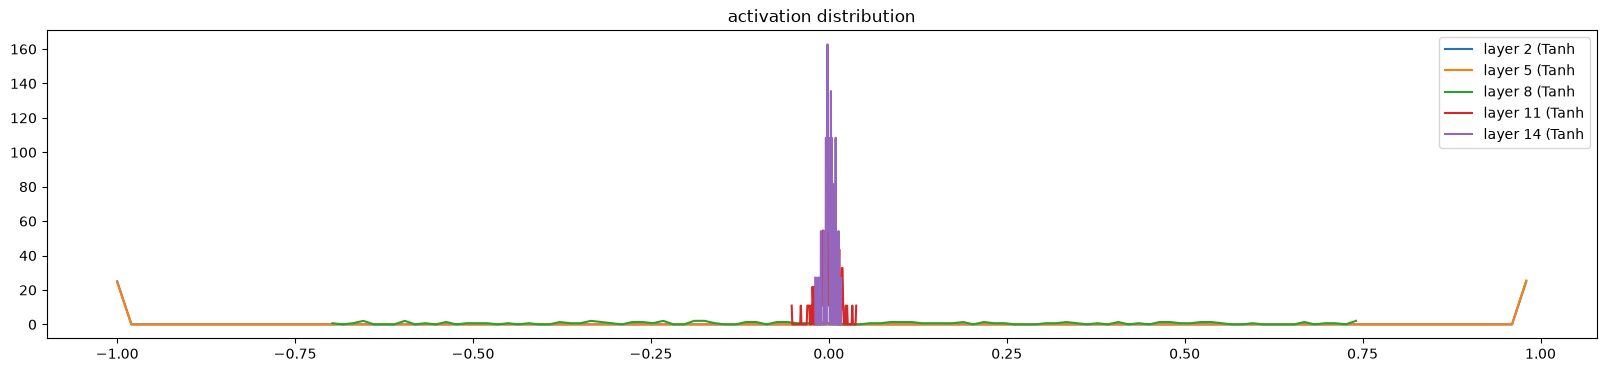

In [9]:
# viz activation distributions in forward pass

plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print(
            "layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%"
            % (
                i,
                layer.__class__.__name__,
                t.mean(),
                t.std(),
                (t.abs() > 0.97).float().mean() * 100,
            )
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__}")
plt.legend(legends)
plt.title("activation distribution")

layer 2 (      Tanh): mean -436.906677, std 1.303398e+11
layer 5 (      Tanh): mean -1474.560059, std 9.086788e+10
layer 8 (      Tanh): mean -0.002917, std 1.125891e+06
layer 11 (      Tanh): mean +0.000008, std 1.381220e+03
layer 14 (      Tanh): mean +0.000000, std 2.552313e+00


Text(0.5, 1.0, 'gradient distribution')

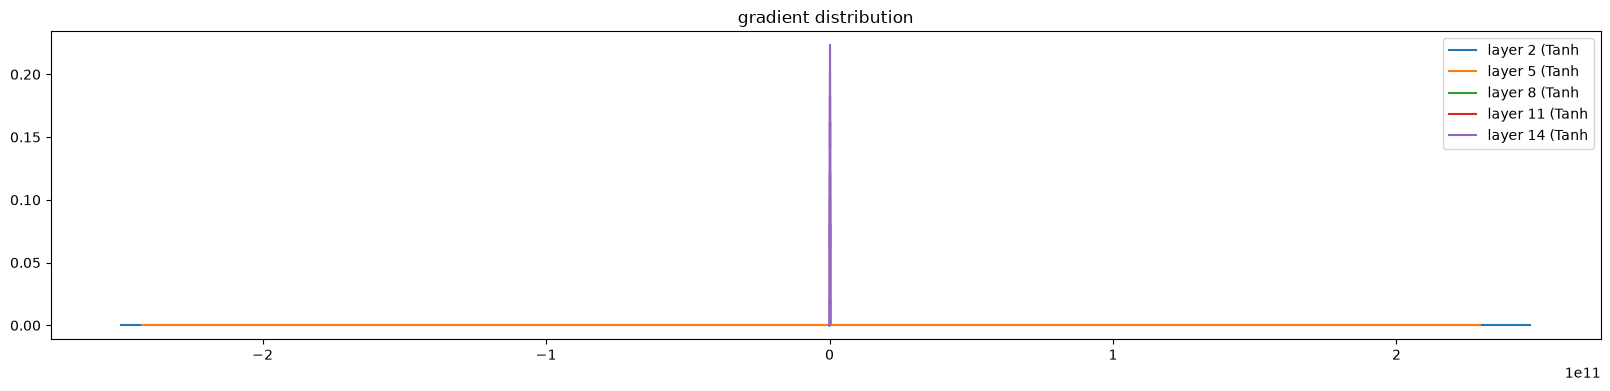

In [10]:
# viz activation gradient distributions in backward pass
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(
            "layer %d (%10s): mean %+f, std %e"
            % (i, layer.__class__.__name__, t.mean(), t.std())
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__}")
plt.legend(legends)
plt.title("gradient distribution")

weight   (27, 10) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight  (30, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight   (1, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight   (1, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight (100, 100) | mean +0.000000 | std 4.383142e+00 | grad:data ratio 5.158240e-05
weight   (1, 100) | mean -0.000186 | std 1.586817e-03 | grad:data ratio 1.316229e-03
weight   (1, 100) | mean -0.028718 | std 2.295169e-01 | grad:data ratio 1.065270e-03
weight (100, 100) | mean +0.008097 | std 1.843571e+01 | grad:data ratio 5.528892e-01
weight   (1, 100) | mean +0.000459 | std 3.596714e-03 | grad:data ratio 2.701509e-02
weight   (1, 100) | mean -0.001509 | std 2.979271e-01 | grad:data ratio 6.564152e-01
weight (100, 100) | mean -0.000076 | std 1.165664e-02 | grad:data ratio 5.291338e-02
weight   (1, 100) | mean -0.000000 | std 2.670460e-09 | grad:data

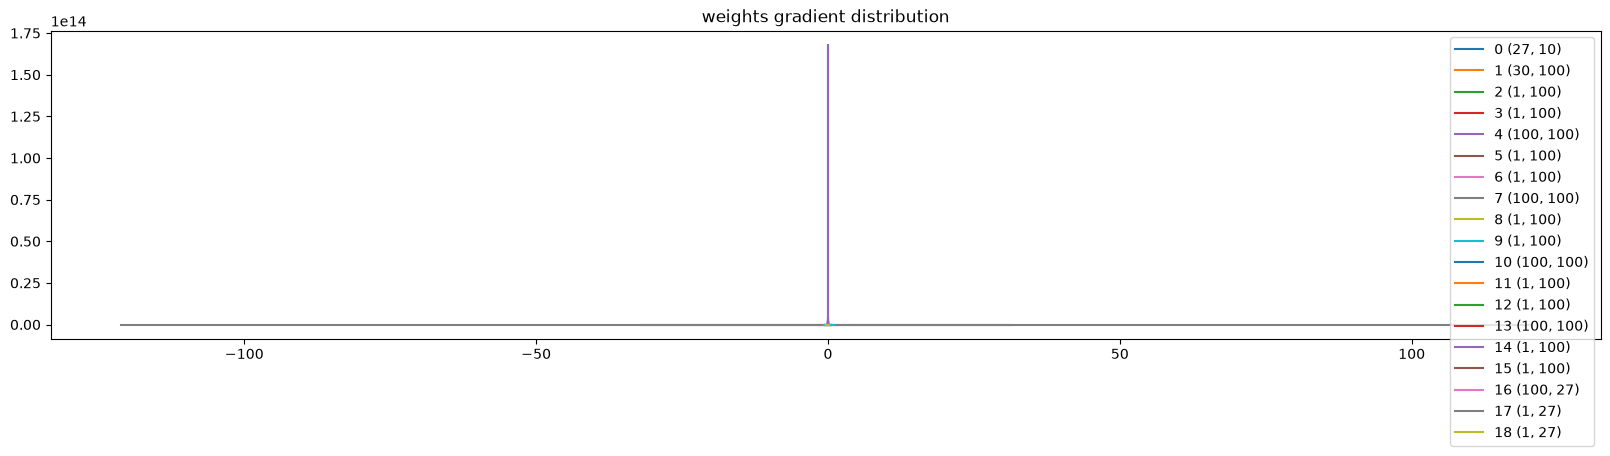

In [11]:
# visualize histograms of ratio of gradient-to-data

plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    # print(p.shape)
    # print(p.ndim)
    if p.ndim == 2:
        print(
            "weight %10s | mean %+f | std %e | grad:data ratio %e"
            % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std())
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"{i} {tuple(p.shape)}")
plt.legend(legends)
plt.title("weights gradient distribution");

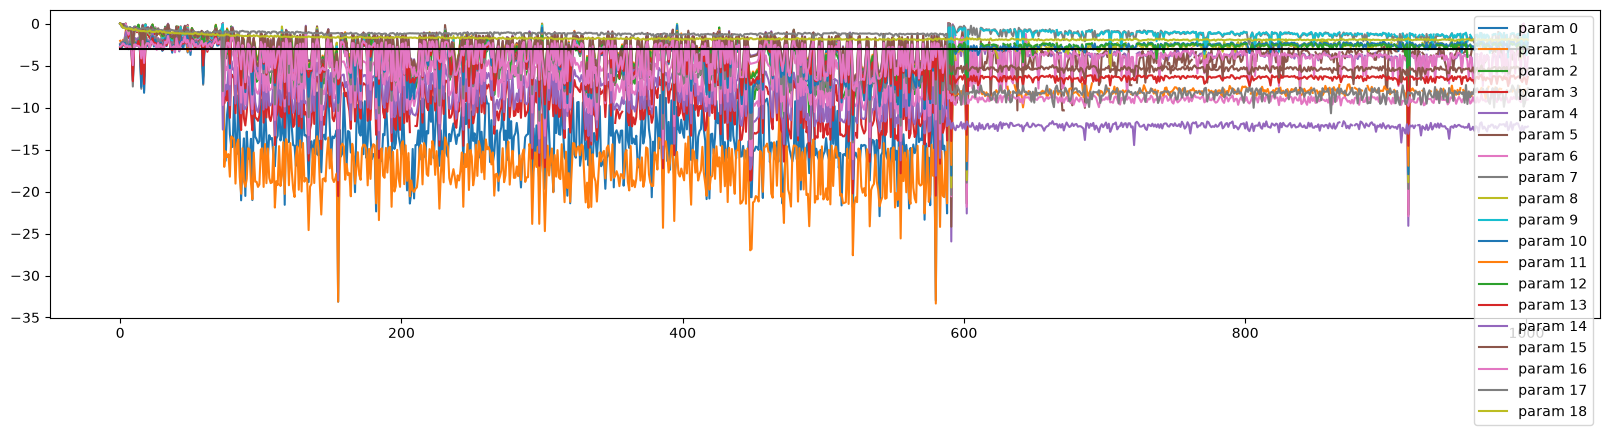

In [12]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([update_to_data[j][i] for j in range(len(update_to_data))])
        legends.append("param %d" % i)
plt.plot(
    [0, len(update_to_data)], [-3, -3], "k"
)  # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [ ]:
update_to_data.shape